In [6]:
!pip install gdown
import gdown
import zipfile
import os

# Dataset Download from Google Drive
file_id = '1219EeGE1XTJVXYaulynJSa3BXGsbNCLx'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'pneumonia_dataset.zip'
gdown.download(url, output, quiet=False)

# Zip extract kora
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('extracted_data')

print("Step 01 Complete: Dataset extracted successfully!")

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=4f6de7dd-06dd-4433-8ca5-c449b65d65f1
To: /content/pneumonia_dataset.zip
100%|██████████| 1.23G/1.23G [00:13<00:00, 88.4MB/s]


Step 01 Complete: Dataset extracted successfully!


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path definition - extraction-er sathe balanced
# Corrected base_path assuming 'train', 'val', 'test' are directly under 'extracted_data'
base_path = 'extracted_data/'

# Data Augmentation & Rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

# Loading data - Path balanced with 'train', 'test', 'val' folders
train_set = train_datagen.flow_from_directory(
    base_path + 'train', target_size=(128, 128), batch_size=32, class_mode='binary')

val_set = test_val_datagen.flow_from_directory(
    base_path + 'val', target_size=(128, 128), batch_size=32, class_mode='binary')

test_set = test_val_datagen.flow_from_directory(
    base_path + 'test', target_size=(128, 128), batch_size=32, class_mode='binary')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [8]:
# CNN Model Setup
model = tf.keras.models.Sequential([
    # Convolutional layers
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Flattening & Dense layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training start - balanced with train_set and val_set
# 5 epochs nile taratari result paben
history = model.fit(train_set, validation_data=val_set, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 651ms/step - accuracy: 0.8349 - loss: 0.3913 - val_accuracy: 0.6875 - val_loss: 0.6670
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9078 - loss: 0.2185 - val_accuracy: 0.7500 - val_loss: 0.6014
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 647ms/step - accuracy: 0.9239 - loss: 0.1917 - val_accuracy: 0.7500 - val_loss: 0.4369
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9331 - loss: 0.1686 - val_accuracy: 0.8125 - val_loss: 0.3944
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 663ms/step - accuracy: 0.9346 - loss: 0.1622 - val_accuracy: 0.8750 - val_loss: 0.2523


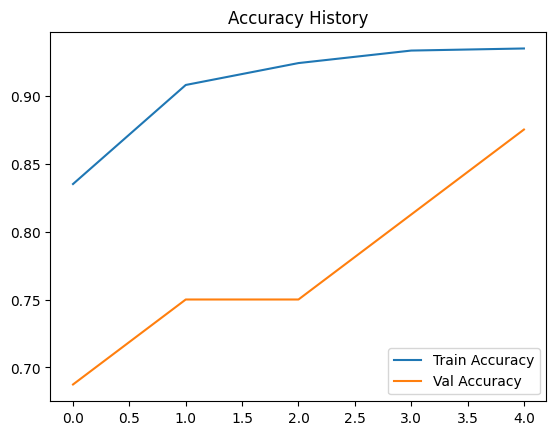

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.8654 - loss: 0.3434
Final Result - Test Accuracy: 86.54%


In [9]:
import matplotlib.pyplot as plt

# 1. Plotting Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy History')
plt.legend()
plt.show()

# 2. Final Test result on unseen images
test_loss, test_acc = model.evaluate(test_set)
print(f"Final Result - Test Accuracy: {test_acc*100:.2f}%")